
### Problem

Classify customer reviews into **positive or negative sentiment** to monitor product feedback.

### Approach

1. **Classical ML**: TF-IDF + Naive Bayes.
2. **Deep Learning (optional)**: LSTM or BERT for higher accuracy.
3. **Preprocessing**: Clean text, remove stopwords, vectorize.

###  Key Insights

* Even small datasets can give reasonable insights with Naïve Bayes.
* Deep learning models outperform classical ML on large datasets.
* Common important words for sentiment: *love, bad, excellent, terrible, happy*.

### Enterprise Use Case

* **Monitor customer satisfaction** in e-commerce, SaaS, or telecom.
* Automatically detect **negative feedback** for immediate action.
* Can be integrated into **dashboards or alert systems** for business decisions.

### 1. Import Libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


### 2. Load Real Dataset


In [3]:
# Replace 'IMDB_Dataset.csv' with your CSV file path
df = pd.read_csv("Data/IMDB Dataset.csv")

print("Dataset Sample:")
print(df.head())

# Encode target variable
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

X = df['review']
y = df['sentiment']



Dataset Sample:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


### 3. Train-Test Split


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 4. TF-IDF Vectorization


In [6]:
tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


### 5. Model Training - Naïve Bayes

In [7]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### 6. Predictions & Evaluation


In [8]:
y_pred = nb_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))



Accuracy: 0.8575
Precision: 0.8564307078763709
Recall: 0.859
F1 Score: 0.8577134298552171


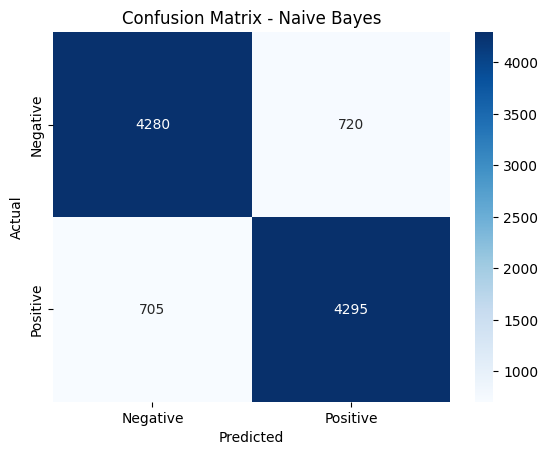

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()
